# TED Talk Sentiment Analysis

This notebook runs sentiment analysis on TED talk transcripts using three different methods, NRC, VADER, and a transformer-based ML model and then compares how the results differ across talk themes.

## 1. Imports

Everything needed for the analysis. spacy handles text preprocessing, nrclex and vaderSentiment are the two lexicon-based sentiment tools, and transformers gives us the ML sentiment model.

In [1]:
import kagglehub
import pandas as pd
import spacy
import os
import ast
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

%matplotlib inline
nltk.download('punkt_tab')

C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\elzes\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Loading the data

The dataset is split across two CSV files. one with talk metadata and one with the transcripts. We join them side by side and drop any rows that don't have a transcript since we can't do much without one.

In [2]:
path = kagglehub.dataset_download("rounakbanik/ted-talks")

main        = pd.read_csv(os.path.join(path, "ted_main.csv"))
transcripts = pd.read_csv(os.path.join(path, "transcripts.csv"))

df = pd.concat([main, transcripts], axis=1)
df = df.drop(columns=["url"])
df = df.dropna(subset=["transcript"]).reset_index(drop=True)
#df.head(100)

df.to_csv("../data/processed/ted_combined.csv", index=False)
print(f"Shape: {df.shape}")

Shape: (2467, 17)


## 3. Text preprocessing

Before running the lexicon-based methods we clean the transcripts, removing stopwords, and short tokens, then lemmatizing what's left (so 'running' becomes 'run', etc.).

We use spacy for this with n_process=6 to batch through transcripts in parallel rather than one by one. The result gets stored in two new columns: clean_tokens (a list) and clean_text (the same thing joined as a string).

The ML model gets the raw transcript instead since it is trained on raw transcripts.

In [3]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess(doc):
    tokens = [t.lemma_ for t in doc
              if not t.is_stop and not t.is_space
              and t.is_alpha and len(t.lemma_) > 2]
    return tokens

texts = df["transcript"].tolist()
df["clean_tokens"] = [preprocess(doc) for doc in nlp.pipe(texts, n_process=6, batch_size=64)]
df["clean_text"]   = df["clean_tokens"].apply(" ".join)
print("done")

done


## 4. NRC emotion analysis

NRC is a lexicon that maps words to emotions, joy, fear, anger, trust, sadness, disgust, surprise, anticipation, which we turn into a basic positive/negative score. It's more granular than VADER since you get individual emotion scores, not just a single polarity number.

analyse_nrc takes either a token list or a raw string and returns the emotion frequency scores. We then collapse those into a single polarity score: positive emotions minus negative ones.

In [4]:
def analyse_nrc(tkns):
    text_object = NRCLex()
    if isinstance(tkns, str):
        text_object.load_raw_text(tkns)
    else:
        text_object.load_token_list(tkns)
    return text_object.affect_frequencies


def get_nrc_polarity(emotions):
    positive = emotions.get("joy", 0) + emotions.get("trust", 0) + emotions.get("anticipation", 0)
    negative = emotions.get("fear", 0) + emotions.get("anger", 0) + emotions.get("sadness", 0) + emotions.get("disgust", 0)
    return positive - negative


df["nrc_anal_clean_tkns"] = df["clean_tokens"].apply(analyse_nrc).apply(get_nrc_polarity)
df["nrc_anal_transcript"] = df["transcript"].apply(analyse_nrc).apply(get_nrc_polarity)
print("done")

done


## 5. VADER sentiment analysis

VADER is another lexicon-based method but it's designed specifically for social text, it allegedly handles punctuation, capitalization, and negations better than NRC. It returns a dict with `pos`, `neg`, `neu`, and `compound` scores.

We derive a simple polarity score the same way as NRC: positive minus negative.

In [5]:
sia = SentimentIntensityAnalyzer()


def get_vader_polarity(emotions):
    return emotions.get("pos", 0) - emotions.get("neg", 0)


df["vader_anal_clean_tkns"] = df["clean_text"].apply(sia.polarity_scores).apply(get_vader_polarity)
df["vader_anal_transcript"] = df["transcript"].apply(sia.polarity_scores).apply(get_vader_polarity)
print("done")

done


## 6. ML sentiment analysis

Transformer models are more powerful but has a 512 token limit since many of them are trained on short tweets or comments, which is way too short for a full TED talk. To get around this we split each transcript into overlapping chunks, score each chunk separately, then average the scores across the whole talk.

The overlap means we don't lose context at chunk boundaries. Any transcript shorter than `size` is passed through as-is to avoid the model choking on tiny inputs. Chunks also allow us to take a peak at the timeline and how emotions change during the TED talk.

In [6]:
sentiment = pipeline("sentiment-analysis")


def chunk_transcript(text, size=50, overlap=5):
    words = text.split()
    chunks = []
    if len(words) < size:
        return [text]
    for i in range(overlap, len(words), size):
        chunk = " ".join(words[i-overlap:i+size])
        if len(chunk.split()) >= size:
            chunks.append(chunk)
    return chunks

def ml_polarity(result):
    score = result[0]["score"]
    return score if result[0]["label"] == "POSITIVE" else -score

def average_chunks(chunks):
    scores = [ml_polarity(sentiment(c)) for c in chunks]
    return sum(scores) / len(scores)

df["ml_anal_transcript"] = df["transcript"].apply(lambda x: average_chunks(chunk_transcript(x)))
print("done")

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


done


## 7. Tag parsing and theme assignment

Each talk has a list of curator-assigned tags stored as a string in the CSV. We parse those back into real lists, then use a keyword map to assign each talk to a broad theme.

The `assign_theme` function scores each theme by counting how many of the talk's tags match that theme's keyword list. Whichever theme gets the most matches wins.

THEME_MAP is a handcrafted mappif of tags to theme, this ensures it is accurate. Please check the report about tagging for more information.

In [7]:
df["tags"] = df["tags"].apply(ast.literal_eval)

In [8]:
THEME_MAP = {
    "Science & Technology": [
        "science", "technology", "computers", "software", "code", "programming",
        "ai", "robots", "virtual reality", "internet", "web", "microsoft", "google",
        "online video", "hack", "demo", "interface design", "open-source", "wikipedia",
        "innovation", "invention", "engineering", "materials", "nanoscale", "chemistry",
        "string theory", "complexity", "simplicity", "rocket science", "telescopes",
        "drones", "biomechanics", "biomimicry", "animation", "gaming", "physics", "data"
    ],
    "Environment & Nature": [
        "environment", "climate change", "sustainability", "green", "pollution",
        "alternative energy", "solar energy", "wind energy", "energy", "water",
        "nature", "ecology", "biodiversity", "oceans", "fish", "animals", "birds",
        "insects", "ants", "bees", "plants", "garden", "trees", "agriculture",
        "natural resources", "natural disaster", "geology", "anthropocene",
        "asteroid", "mining", "plastic", "solar system"
    ],
    "Society & Politics": [
        "politics", "policy", "democracy", "government", "law", "corruption",
        "military", "war", "terrorism", "violence", "crime", "prison", "evil",
        "inequality", "race", "gender", "women", "activism", "social change",
        "global issues", "global development", "state-building", "united states",
        "europe", "africa", "asia", "china", "india", "brazil", "south america",
        "new york", "cities", "urban planning", "infrastructure", "community",
        "world cultures", "ancient world", "history", "human origins", "humanity",
        "culture", "society"
    ],
    "Business & Economics": [
        "business", "economics", "entrepreneur", "investment", "microfinance",
        "money", "marketing", "consumerism", "shopping", "work", "leadership",
        "productivity", "work-life balance", "goal-setting", "success", "innovation",
        "women in business", "telecom", "transportation", "cars", "infrastructure"
    ],
    "Health & Medicine": [
        "health", "medicine", "disease", "cancer", "aids", "ebola", "virus",
        "bacteria", "vaccines", "health care", "public health", "heart health",
        "obesity", "aging", "genetics", "dna", "biotech", "biology", "microbiology",
        "neuroscience", "brain", "cognitive science", "prosthetics", "illness",
        "depression", "mental health", "suicide", "alzheimer's", "bioethics",
        "astrobiology", "death"
    ],
    "Arts & Culture": [
        "art", "design", "architecture", "film", "movies", "music", "performance",
        "dance", "theater", "photography", "literature", "books", "poetry",
        "writing", "storytelling", "spoken word", "comedy", "humor", "animation",
        "typography", "fashion", "beauty", "origami", "museums", "library",
        "industrial design", "product design", "science and art", "performance art",
        "live music", "singer", "violin", "piano", "guitar", "cello", "vocals",
        "composing", "conducting", "ted brain trust", "culture", "society"
    ],
    "Psychology & Mind": [
        "psychology", "happiness", "motivation", "potential", "personal growth",
        "decision-making", "choice", "mind", "memory", "consciousness", "identity",
        "self", "personality", "introvert", "body language", "fear", "empathy",
        "compassion", "love", "relationships", "evolutionary psychology",
        "behavior", "morality", "curiosity", "play", "creativity"
    ],
    "Education & Learning": [
        "education", "teaching", "children", "parenting", "youth", "learning",
        "wunderkind", "presentation", "communication", "language", "math",
        "statistics", "visualizations", "macarthur grant", "ted prize", "ted fellows",
        "tedx", "interview", "society"
    ],
    "Space & Exploration": [
        "space", "cosmos", "universe", "astronomy", "nasa", "moon", "mars",
        "planets", "flight", "aircraft", "exploration", "adventure", "travel",
        "dark matter", "big bang", "extraterrestrial life", "submarine", "physics"
    ],
    "Religion & Philosophy": [
        "religion", "christianity", "god", "atheism", "buddhism", "faith",
        "philosophy", "evolution", "life", "time", "charter for compassion",
        "ancient world"
    ],
    "Society & Lifestyle": [
        "food", "sex", "family", "sports", "extreme sports", "social media",
        "news", "media", "entertainment", "map", "smell", "senses", "illusion",
        "magic", "meme", "toy", "materials", "narcotics", "sociology",
        "anthropology", "archaeology", "paleontology", "dinosaurs", "primates",
        "apes", "poverty", "philanthropy", "disaster relief", "peace",
        "collaboration", "human origins", "intelligence", "culture", "society"
    ],
}


In [9]:
def assign_theme(tags):
    scores = {theme: 0 for theme in THEME_MAP}
    for tag in tags:
        tag = tag.lower()
        for theme, keywords in THEME_MAP.items():
            if tag in keywords:
                scores[theme] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "Other"


df["theme"] = df["tags"].apply(assign_theme)
print(df["theme"].value_counts())

theme
Society & Politics       614
Science & Technology     511
Arts & Culture           443
Health & Medicine        235
Environment & Nature     206
Business & Economics     133
Education & Learning      93
Psychology & Mind         88
Society & Lifestyle       74
Space & Exploration       47
Religion & Philosophy     23
Name: count, dtype: int64


## 8. Results

Now that we have sentiment scores from all three methods and a theme for each talk, we can compare how they line up. Three plots below:

1. Score distributions, how each method's scores are spread across the dataset. We are checking both running on the raw text and cleaned tokens.
2. NRC vs VADER scatter, do the two lexicon methods agree with each other? We are checking both running on the raw text and cleaned tokens.
3. Average scores by theme, which topics tend to score more positive or negative

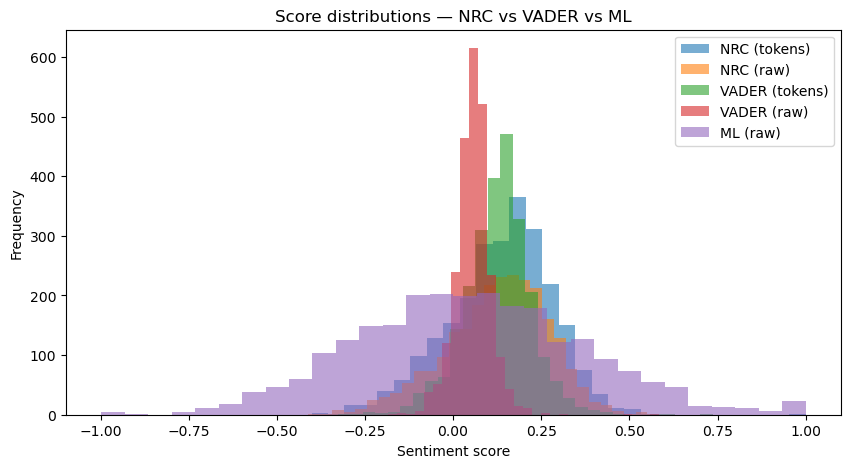

In [10]:
# Score distributions for all three methods
plt.figure(figsize=(10, 5))
plt.hist(df["nrc_anal_clean_tkns"],  bins=30, alpha=0.6, label="NRC (tokens)")
plt.hist(df["nrc_anal_transcript"],  bins=30, alpha=0.6, label="NRC (raw)")
plt.hist(df["vader_anal_clean_tkns"], bins=30, alpha=0.6, label="VADER (tokens)")
plt.hist(df["vader_anal_transcript"], bins=30, alpha=0.6, label="VADER (raw)")
plt.hist(df["ml_anal_transcript"],   bins=30, alpha=0.6, label="ML (raw)")
plt.xlabel("Sentiment score")
plt.ylabel("Frequency")
plt.title("Score distributions — NRC vs VADER vs ML")
plt.legend()
plt.show()

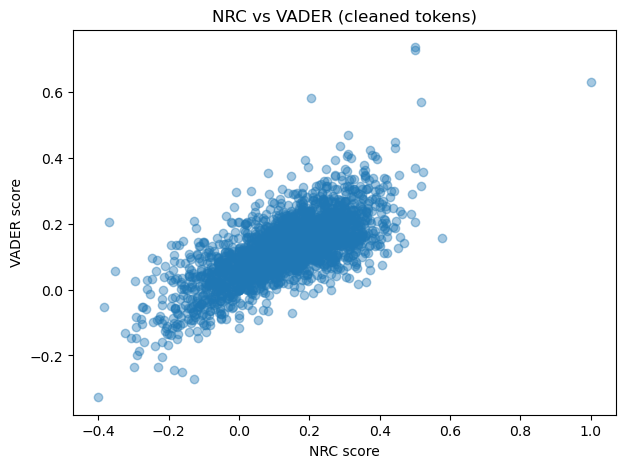

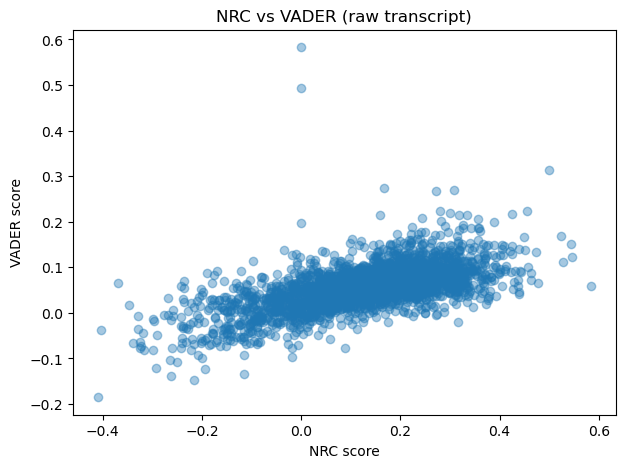

In [11]:
# NRC vs VADER on cleaned tokens
plt.figure(figsize=(7, 5))
plt.scatter(df["nrc_anal_clean_tkns"], df["vader_anal_clean_tkns"], alpha=0.4)
plt.xlabel("NRC score")
plt.ylabel("VADER score")
plt.title("NRC vs VADER (cleaned tokens)")
plt.show()

# NRC vs VADER on raw transcript
plt.figure(figsize=(7, 5))
plt.scatter(df["nrc_anal_transcript"], df["vader_anal_transcript"], alpha=0.4)
plt.xlabel("NRC score")
plt.ylabel("VADER score")
plt.title("NRC vs VADER (raw transcript)")
plt.show()

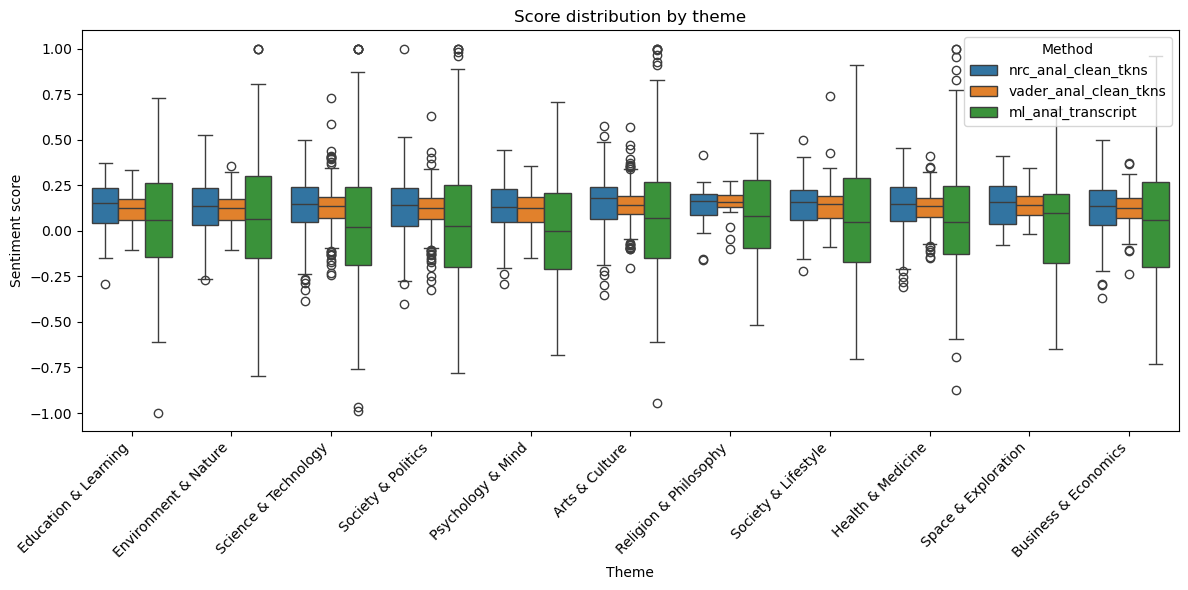

In [12]:
# Score distribution per theme — all three methods side by side
df_long = df.melt(
    id_vars="theme",
    value_vars=["nrc_anal_clean_tkns", "vader_anal_clean_tkns", "ml_anal_transcript"],
    var_name="method",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.boxplot(x="theme", y="score", hue="method", data=df_long)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Theme")
plt.ylabel("Sentiment score")
plt.title("Score distribution by theme")
plt.legend(title="Method")
plt.tight_layout()
plt.show()

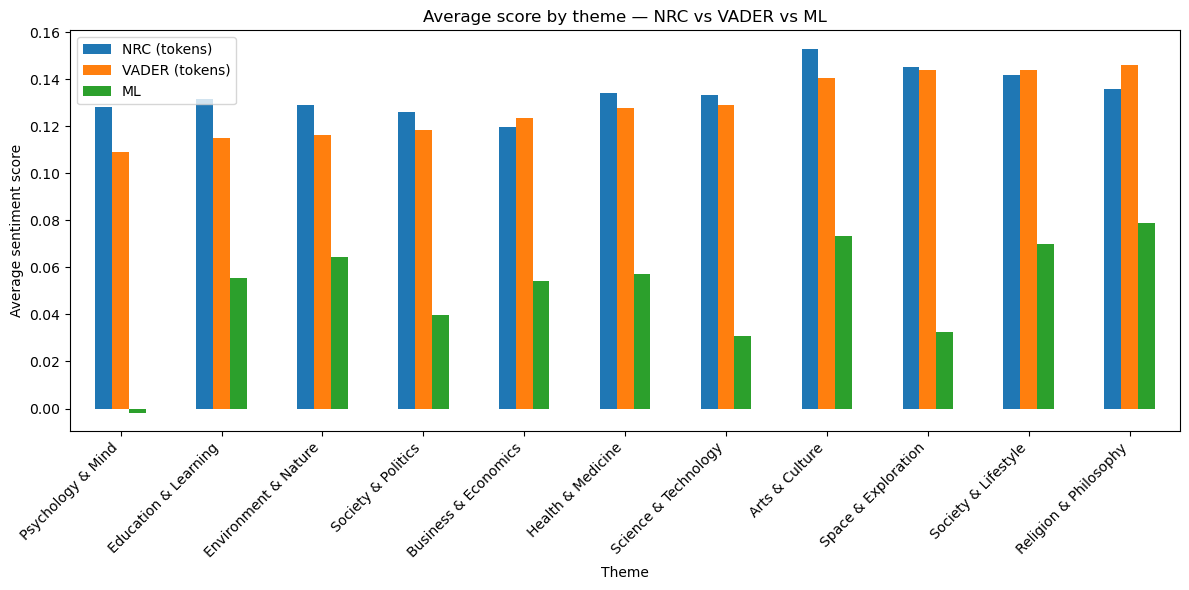

In [13]:
# Average score per theme
theme_means = df.groupby("theme")[["nrc_anal_clean_tkns", "vader_anal_clean_tkns", "ml_anal_transcript"]] \
               .mean().sort_values("vader_anal_clean_tkns")

theme_means.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Theme")
plt.ylabel("Average sentiment score")
plt.title("Average score by theme — NRC vs VADER vs ML")
plt.xticks(rotation=45, ha="right")
plt.legend(["NRC (tokens)", "VADER (tokens)", "ML"])
plt.tight_layout()
plt.show()